In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

ANALYSIS OF VNL MEN 2023 DATASET

In [7]:
df=pd.read_csv(r"C:\Users\Admin\.vscode-shared\vnl_men_2023)\VNL2023.csv")
print(df.head(10))

                    Player    Country  Age  Attack  Block  Serve   Set   Dig  \
0            Ichikawa Yuki      Japan   28   15.80   1.13   1.40  0.07  4.80   
1              Romano Yuri      Italy   26   12.33   1.07   1.47  0.00  3.87   
2         Abdel-Aziz Nimir  Nederland   31   15.33   0.67   2.08  0.00  3.17   
3      Herrera Jaime Jesus       Cuba   28   15.00   0.92   1.75  0.00  3.33   
4            Takahashi Ran      Japan   22   11.53   0.67   1.00  0.07  6.40   
5           Luburic Drazen     Serbia   30   14.33   0.58   1.08  0.00  4.25   
6              Urnaut Tine   Slovenia   35   12.62   0.31   1.38  0.00  5.85   
7            Zhang Jingyin      China   24   13.50   1.83   1.42  0.00  3.42   
8               Souza Alen     Brazil   29   12.46   0.62   0.54  0.00  4.15   
9  Souza Ricardo Lucarelli     Brazil   31   11.85   0.92   1.46  0.15  5.38   

   Receive Position  
0     5.60       OH  
1     0.00       OP  
2     0.25       OP  
3     0.17       OP  
4     5.0

CHECK MISSING DATA AND REMOVE DUPLICATE

In [8]:
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64


In [9]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Int64Index: 131 entries, 0 to 130
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Player    131 non-null    object 
 1   Country   131 non-null    object 
 2   Age       131 non-null    int64  
 3   Attack    131 non-null    float64
 4   Block     131 non-null    float64
 5   Serve     131 non-null    float64
 6   Set       131 non-null    float64
 7   Dig       131 non-null    float64
 8   Receive   131 non-null    float64
 9   Position  131 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 11.3+ KB


(131, 10)

ANALYSIS OF VOLLEYBALL SKILL 

1.BEST  ATTACKER IN TOUNAMENT 

In [10]:
print(df.sort_values('Attack',ascending=False).head(1))

          Player Country  Age  Attack  Block  Serve   Set  Dig  Receive  \
0  Ichikawa Yuki   Japan   28    15.8   1.13    1.4  0.07  4.8      5.6   

  Position  
0       OH  


2.BEST BLOCKER OF THE TOUNAMENT


In [11]:
print(df.sort_values('Block',ascending=False).head(1))

           Player    Country  Age  Attack  Block  Serve  Set   Dig  Receive  \
29  Loser Agustin  Argentina   26    7.92   4.08   0.92  0.0  2.31     0.69   

   Position  
29       MB  


COUNTRIES WHICH PLAY OFFENSIVE GAME

In [12]:
teams=df.groupby('Country')['Attack'].mean().sort_values(ascending=False).head(5)
print(teams)

Country
France    6.670000
Japan     6.595000
Cuba      6.344286
Serbia    5.998750
Italy     5.965000
Name: Attack, dtype: float64


COUNTRIES WHICH PLAY DEFENSIVE GAME

In [13]:
team=df.groupby('Country')['Block'].mean().sort_values(ascending=False).head(5)
print(team)

Country
Italy        1.261250
Argentina    1.060000
Serbia       1.037500
Cuba         0.965714
Iran         0.932222
Name: Block, dtype: float64


COUNTRY HAVE BEST SERVER 

In [14]:
print(df.sort_values('Serve',ascending=False).head(1))

             Player    Country  Age  Attack  Block  Serve  Set   Dig  Receive  \
2  Abdel-Aziz Nimir  Nederland   31   15.33   0.67   2.08  0.0  3.17     0.25   

  Position  
2       OP  


POSITION WITH  DOMINANCE IN SKILL

In [15]:
pos1=df.groupby('Position')['Receive'].mean().sort_values(ascending=False).head(1)
print(pos1)
pos2=df.groupby('Position')['Set'].mean().sort_values(ascending=False).head(1)
print(pos2)
pos3=df.groupby('Position')['Block'].mean().sort_values(ascending=False).head(1)
print(pos3)
pos4=df.groupby('Position')['Attack'].mean().sort_values(ascending=False).head(1)
print(pos4)
pos5=df.groupby('Position')['Dig'].mean().sort_values(ascending=False).head(1)
print(pos5)
pos6=df.groupby('Position')['Serve'].mean().sort_values(ascending=False).head(1)
print(pos6)

Position
L    3.839375
Name: Receive, dtype: float64
Position
S    17.879375
Name: Set, dtype: float64
Position
MB    1.525625
Name: Block, dtype: float64
Position
OP    9.326
Name: Attack, dtype: float64
Position
L    7.098125
Name: Dig, dtype: float64
Position
OP    0.8024
Name: Serve, dtype: float64


PLAYER WHICH GOOD IN BOTH BLOCK AND ATTACK

In [16]:
atck=df.sort_values('Attack',ascending=False).head(3)
block=df.sort_values('Block',ascending=False).head(3)
df1=atck.merge(block)
print(df1)

       Player Country  Age  Attack  Block  Serve  Set  Dig  Receive Position
0  Faure Theo  France   24   15.25    3.0    1.5  0.0  5.0      0.0       OP


PLAYER GOOD IN RECEIVE AND ATTACK

In [17]:
r=df.sort_values('Receive',ascending=False).head(10)
atck2=df.sort_values('Attack',ascending=False).head(10)
df2=r.merge(atck2)
print(df2)

          Player   Country  Age  Attack  Block  Serve   Set   Dig  Receive  \
0  Ichikawa Yuki     Japan   28   15.80   1.13   1.40  0.07  4.80      5.6   
1    Urnaut Tine  Slovenia   35   12.62   0.31   1.38  0.00  5.85      5.0   

  Position  
0       OH  
1       OH  


COUNTRIES WITH ALL ROUND PERFORMANCE

In [18]:
df['all_rounder']=df['Attack']+ df['Block'] +df['Serve']+df['Set']+df['Dig']+df['Receive']
print(df.groupby('Country')['all_rounder'].mean().sort_values(ascending=False))

Country
Italy        17.356250
Argentina    17.152500
Japan        16.370000
Slovenia     16.018750
France       15.489000
Serbia       15.326250
Cuba         14.597143
Nederland    14.547143
Canada       14.248571
Poland       13.831000
Bulgaria     13.146250
Brazil       13.063750
USA          13.022222
China        12.373750
Germany      11.590000
Iran         11.533333
Name: all_rounder, dtype: float64


HEATMAP SHOW RELATION BETWEEN THE SKILLS 

C:\Users\Admin\AppData\Local\Temp\ipykernel_14456\2473856703.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(method="pearson"),annot=True ,cmap='coolwarm')


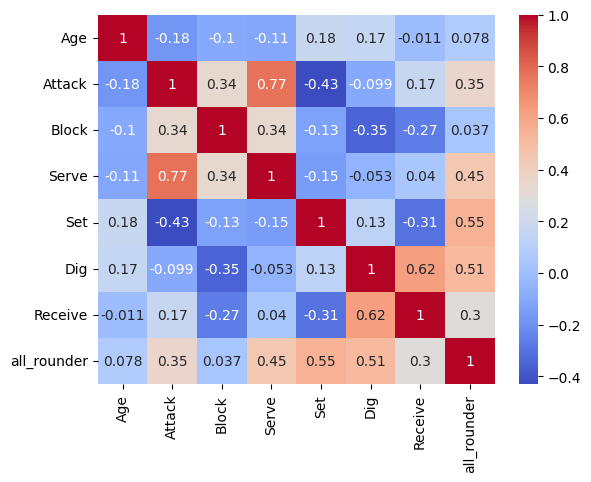

In [19]:
sns.heatmap(df.corr(method="pearson"),annot=True ,cmap='coolwarm')
plt.show()

COMPARISON BETWEEN ATTACK VS BLOCK

C:\Users\Admin\AppData\Local\Temp\ipykernel_14456\3938006654.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  top_players = df.nlargest(10, 'Attack').append(df.nlargest(10, 'Block')).drop_duplicates()


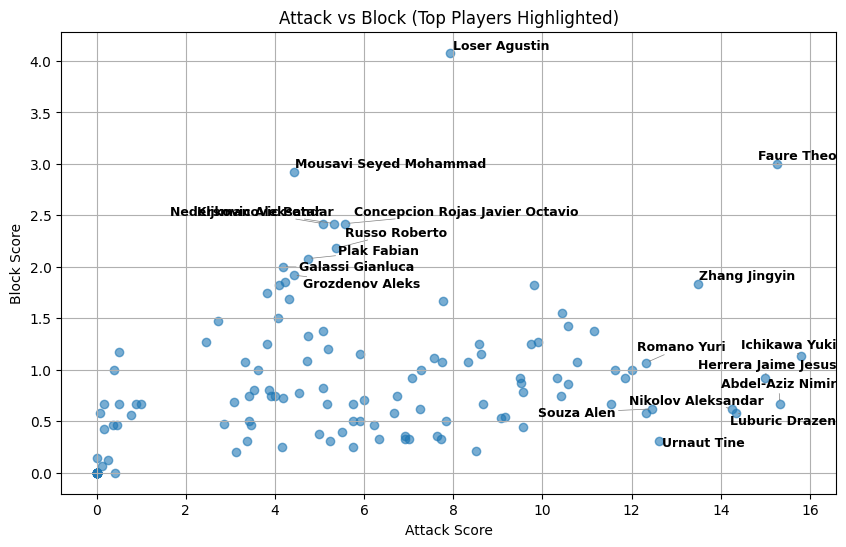

In [20]:
from adjustText import adjust_text

plt.figure(figsize=(10,6))

plt.scatter(df['Attack'], df['Block'], alpha=0.6)

# take top players only (we can change number in this)
top_players = df.nlargest(10, 'Attack').append(df.nlargest(10, 'Block')).drop_duplicates()

texts = []

for row in top_players.itertuples():
    texts.append(
        plt.text(row.Attack, row.Block, row.Player, fontsize=9, fontweight='bold')
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.xlabel("Attack Score")
plt.ylabel("Block Score")
plt.title("Attack vs Block (Top Players Highlighted)")
plt.grid(True)
plt.show()

COMPARISON BETWEEEN COUNTRIES WITH THIER ALL ROUND ABILITY

C:\Users\Admin\AppData\Local\Temp\ipykernel_14456\1128721691.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Country'],y=df['all_rounder'],palette='coolwarm')


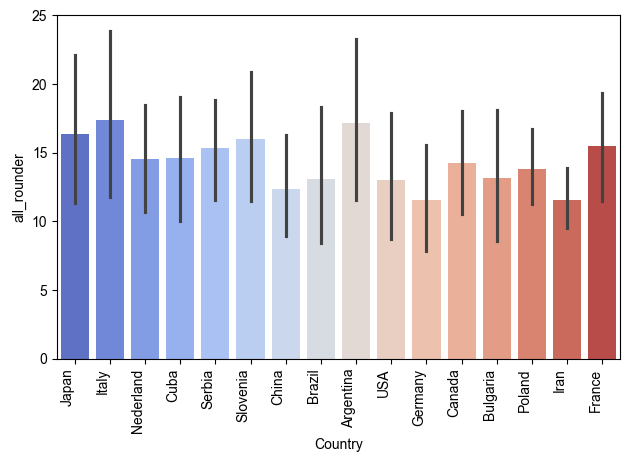

In [21]:
sns.barplot(x=df['Country'],y=df['all_rounder'],palette='coolwarm')
plt.xticks(rotation=90,ha='right')
plt.tight_layout()
sns.set_style('darkgrid')
plt.show()